# 🧠 Implementación y Simulación del Perceptrón Simple desde Cero

**Curso:** Inteligencia Artificial
**Actividad:** Perceptrón de Rosenblatt — implementación en NumPy puro (sin scikit-learn)
**Simulador interactivo desplegado:** https://perceptron-3lsq84czlgcncqnhgoiqh9.streamlit.app
**Repositorio:** https://github.com/Calamar49/Perceptron

Este cuaderno documenta la implementación de la clase `Perceptron`, los
experimentos de entrenamiento pedidos por la guía (compuertas lógicas AND, OR
y XOR), las gráficas de convergencia y frontera de decisión, y las respuestas
al cuestionario de análisis. Las secciones marcadas **`EXTRA`** son contenido
adicional, más allá de lo pedido por la guía.

## Tabla de contenido

1. [Fundamento teórico](#1)
2. [Construcción de la clase `Perceptron`](#2)
3. [Funciones auxiliares de graficación](#3)
4. [Datos de entrenamiento](#4)
5. [Experimentos: AND, OR, XOR](#5)
6. [`EXTRA` Trayectoria de los pesos en el espacio de entrenamiento](#6)
7. [`EXTRA` Comparación conjunta de convergencia](#7)
8. [`EXTRA` Exactitud (accuracy) final de cada compuerta](#8)
9. [`EXTRA` Compuerta bonus: NAND](#9)
10. [Comparación de tasa de aprendizaje (η = 0.1 vs η = 0.01)](#10)
11. [Cuestionario y análisis](#11)
12. [`EXTRA` Conclusiones generales y referencias](#12)


<a id="1"></a>
## 1. Fundamento teórico

El Perceptrón toma un vector de entrada $\mathbf{x}$, calcula la combinación
lineal $z = \mathbf{w} \cdot \mathbf{x} + b$ (pesos $\mathbf{w}$ más un
sesgo $b$), y aplica una función de activación escalón (Heaviside):

$$\hat{y} = \begin{cases} 1 & \text{si } z \geq 0 \\ 0 & \text{si } z < 0 \end{cases}$$

**Regla de actualización de pesos** — para cada muestra de entrenamiento, el
error es $e = y - \hat{y}$. Si $e \neq 0$, los pesos y el sesgo se ajustan:

$$\mathbf{w} \leftarrow \mathbf{w} + \eta \, e \, \mathbf{x} \qquad\qquad b \leftarrow b + \eta \, e$$

donde $\eta$ (`learning_rate`) es la tasa de aprendizaje. El entrenamiento se
repite por épocas hasta que no haya errores (convergencia) o se agote el
número máximo de épocas.


<a id="2"></a>
## 2. Construcción de la clase `Perceptron`

Implementada únicamente con `numpy` — **no se usa scikit-learn ni ningún
otro framework de ML**, tal como exige la guía. También se guarda un
historial de pesos por época (`weights_history`), usado más adelante para
graficar la trayectoria de entrenamiento (sección 6, `EXTRA`).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Misma paleta que el simulador desplegado (Streamlit Cloud / Hugging Face),
# para que notebook, app y simulador interactivo se vean como un solo trabajo.
COLOR_C0, COLOR_C1, COLOR_ACCENT, COLOR_DIM, COLOR_INK, COLOR_BG, COLOR_LINE = (
    "#1a5fb4", "#c1440e", "#0a8f78", "#e4dcc7", "#211d15", "#fffdf8", "#d9d0bd",
)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.facecolor"] = COLOR_BG
plt.rcParams["axes.facecolor"] = COLOR_BG
plt.rcParams["font.family"] = "monospace"


def estilizar_ejes(ax, titulo):
    ax.set_title(titulo, fontsize=12, fontweight="bold", color=COLOR_INK, pad=10)
    ax.tick_params(colors=COLOR_INK, labelsize=9)
    for spine in ax.spines.values():
        spine.set_color(COLOR_LINE)
    ax.xaxis.label.set_color(COLOR_INK)
    ax.yaxis.label.set_color(COLOR_INK)
    ax.grid(alpha=0.25, color=COLOR_LINE)


class Perceptron:
    def __init__(self, input_size, learning_rate=0.1, epochs=100):
        self.lr = learning_rate
        self.epochs = epochs
        # Inicializacion de pesos y sesgo en ceros
        self.weights = np.zeros(input_size)
        self.bias = 0.0
        self.errors_history = []
        self.weights_history = [(self.weights.copy(), self.bias)]  # EXTRA: para graficar la trayectoria

    def activation_function(self, z):
        # Funcion escalon de Heaviside
        return 1 if z >= 0 else 0

    def predict(self, x):
        z = np.dot(x, self.weights) + self.bias
        return self.activation_function(z)

    def fit(self, X, y):
        """Entrena el perceptron actualizando pesos y bias segun la regla de aprendizaje."""
        for epoch in range(self.epochs):
            total_errors = 0
            for xi, target in zip(X, y):
                prediction = self.predict(xi)
                error = target - prediction
                if error != 0:
                    self.weights += self.lr * error * xi
                    self.bias += self.lr * error
                    total_errors += int(error != 0)
            self.errors_history.append(total_errors)
            self.weights_history.append((self.weights.copy(), self.bias))
            if total_errors == 0:
                print(f"Convergencia alcanzada en la epoca {epoch + 1}")
                break
        else:
            print(f"No convergio en {self.epochs} epocas (errores en la ultima: {total_errors})")

    def accuracy(self, X, y):
        """EXTRA: exactitud (accuracy) del modelo ya entrenado sobre un conjunto de datos."""
        predicciones = np.array([self.predict(xi) for xi in X])
        return float(np.mean(predicciones == y))


<a id="3"></a>
## 3. Funciones auxiliares de graficación

Una para la curva de convergencia (épocas vs. número de errores) y otra para
la frontera de decisión (Decision Boundary): la recta $w_1 x_1 + w_2 x_2 + b = 0$,
despejando $x_2 = -\dfrac{w_1 x_1 + b}{w_2}$.


In [2]:
def graficar_convergencia(perceptron, titulo, ax=None):
    propio = ax is None
    if propio:
        _, ax = plt.subplots(figsize=(5, 3.5))
    epocas = list(range(1, len(perceptron.errors_history) + 1))
    ax.fill_between(epocas, perceptron.errors_history, step="mid", color=COLOR_DIM, alpha=0.7)
    ax.plot(epocas, perceptron.errors_history, drawstyle="steps-mid", color=COLOR_INK, linewidth=1.2)
    estilizar_ejes(ax, f"Convergencia — {titulo}")
    ax.set_xlabel("Época")
    ax.set_ylabel("Número de errores")
    if propio:
        plt.tight_layout()
        plt.show()


def graficar_frontera(X, y, perceptron, titulo, ax=None):
    propio = ax is None
    if propio:
        _, ax = plt.subplots(figsize=(4.5, 4.5))
    for clase, color, marcador in [(0, COLOR_C0, "o"), (1, COLOR_C1, "s")]:
        mascara = y == clase
        ax.scatter(X[mascara, 0], X[mascara, 1], c=color, marker=marcador,
                   s=160, edgecolors="white", linewidths=1.5, label=f"clase {clase}", zorder=3)

    w1, w2 = perceptron.weights
    b = perceptron.bias
    x1_vals = np.linspace(-0.5, 1.5, 100)
    if abs(w2) > 1e-9:
        x2_vals = -(w1 * x1_vals + b) / w2
        ax.plot(x1_vals, x2_vals, "--", color=COLOR_INK, linewidth=2, label="frontera de decisión")
    else:
        ax.axvline(-b / w1 if abs(w1) > 1e-9 else 0, linestyle="--", color=COLOR_INK,
                   linewidth=2, label="frontera de decisión")

    estilizar_ejes(ax, f"Frontera de decisión — {titulo}")
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
    leg = ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    for text in leg.get_texts():
        text.set_color(COLOR_INK)
    if propio:
        plt.tight_layout()
        plt.show()


<a id="4"></a>
## 4. Datos de entrenamiento

Las cuatro combinaciones de entrada binaria ($x_1, x_2 \in \{0, 1\}$) y las
etiquetas correspondientes a cada compuerta lógica.


In [3]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])

y_and = np.array([0, 0, 0, 1])
y_or  = np.array([0, 1, 1, 1])
y_xor = np.array([0, 1, 1, 0])

print("Entradas X:\n", X)
print("AND:", y_and, " | OR:", y_or, " | XOR:", y_xor)


Entradas X:
 [[0 0]
 [0 1]
 [1 0]
 [1 1]]
AND: [0 0 0 1]  | OR: [0 1 1 1]  | XOR: [0 1 1 0]


<a id="5"></a>
## 5. Experimentos: AND, OR y XOR
### Experimento 1 — Compuerta AND

In [4]:
perceptron_and = Perceptron(input_size=2, learning_rate=0.1, epochs=100)
perceptron_and.fit(X, y_and)
print("Pesos finales:", perceptron_and.weights, " | Bias final:", perceptron_and.bias)


Convergencia alcanzada en la epoca 4
Pesos finales: [0.2 0.1]  | Bias final: -0.20000000000000004


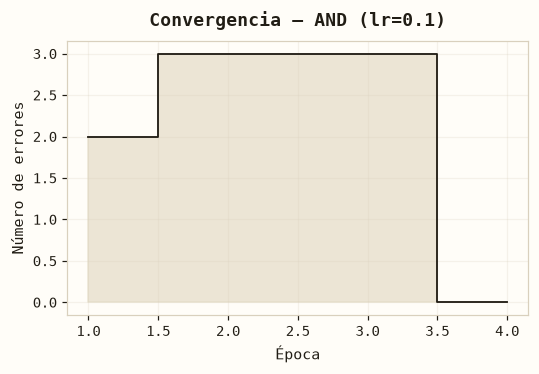

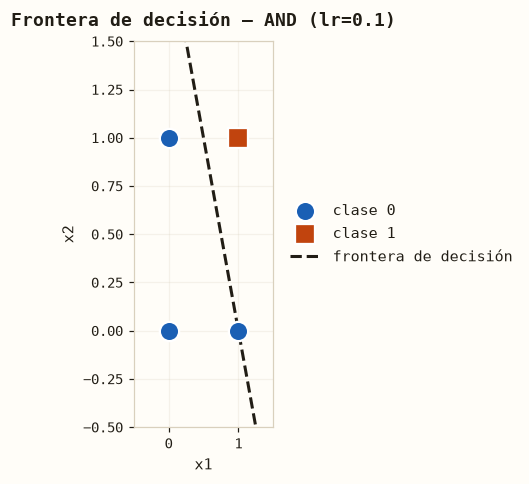

In [5]:
graficar_convergencia(perceptron_and, "AND (lr=0.1)")
graficar_frontera(X, y_and, perceptron_and, "AND (lr=0.1)")


### Experimento 2 — Compuerta OR

In [6]:
perceptron_or = Perceptron(input_size=2, learning_rate=0.1, epochs=100)
perceptron_or.fit(X, y_or)
print("Pesos finales:", perceptron_or.weights, " | Bias final:", perceptron_or.bias)


Convergencia alcanzada en la epoca 4
Pesos finales: [0.1 0.1]  | Bias final: -0.1


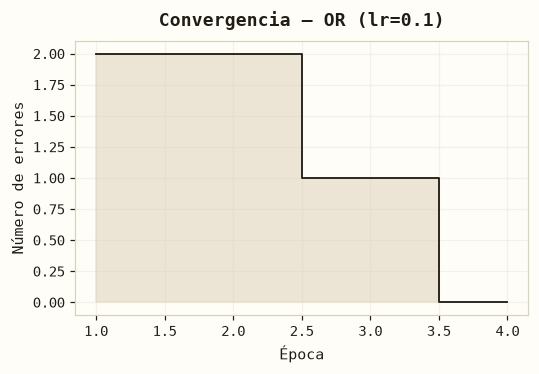

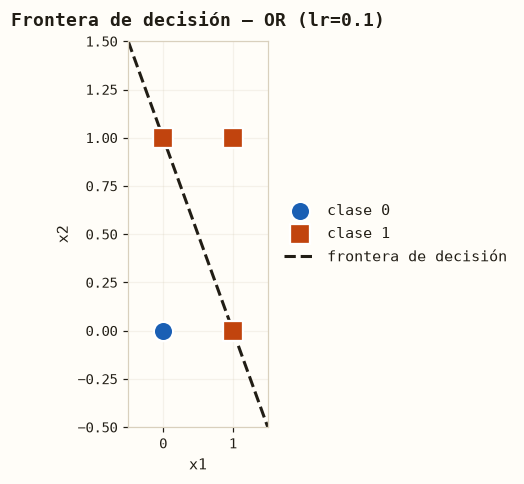

In [7]:
graficar_convergencia(perceptron_or, "OR (lr=0.1)")
graficar_frontera(X, y_or, perceptron_or, "OR (lr=0.1)")


### Experimento 3 — Compuerta XOR (el reto de Minsky & Papert)

XOR **no es linealmente separable** — no existe ninguna recta que separe las
clases 0 y 1 en el plano. Se espera que el Perceptrón simple **no converja**.


In [8]:
perceptron_xor = Perceptron(input_size=2, learning_rate=0.1, epochs=100)
perceptron_xor.fit(X, y_xor)
print("Pesos finales:", perceptron_xor.weights, " | Bias final:", perceptron_xor.bias)
print("Errores en las ultimas 10 epocas:", perceptron_xor.errors_history[-10:])


No convergio en 100 epocas (errores en la ultima: 4)
Pesos finales: [-0.1  0. ]  | Bias final: 0.0
Errores en las ultimas 10 epocas: [4, 4, 4, 4, 4, 4, 4, 4, 4, 4]


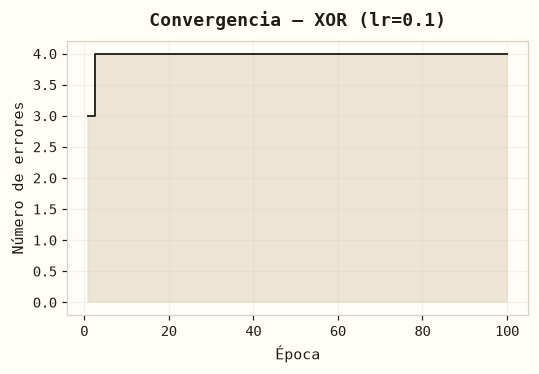

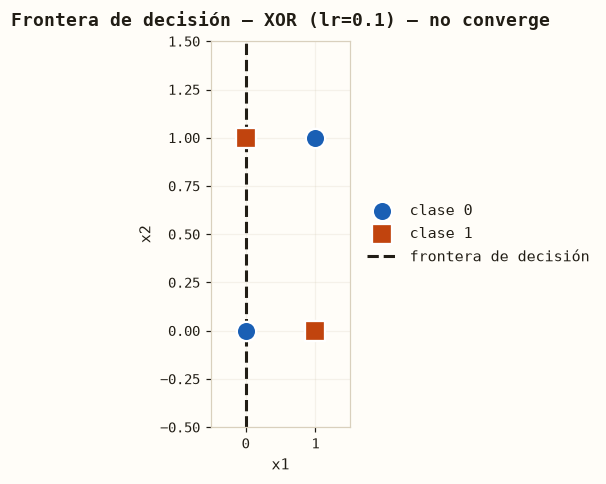

In [9]:
graficar_convergencia(perceptron_xor, "XOR (lr=0.1)")
graficar_frontera(X, y_xor, perceptron_xor, "XOR (lr=0.1) — no converge")


<a id="6"></a>
## 6. `EXTRA` Trayectoria de los pesos en el espacio de entrenamiento

Más allá de mostrar solo el resultado final, aquí se grafica **cómo se mueve**
el vector de pesos $(w_1, w_2)$ época tras época — el "camino" que recorre el
Perceptrón mientras aprende. Para AND y OR, el camino termina y se detiene
apenas encuentra una solución válida. Para XOR, el camino **nunca se detiene**:
sigue dando vueltas indefinidamente porque ninguna posición de $(w_1, w_2)$
resuelve el problema.


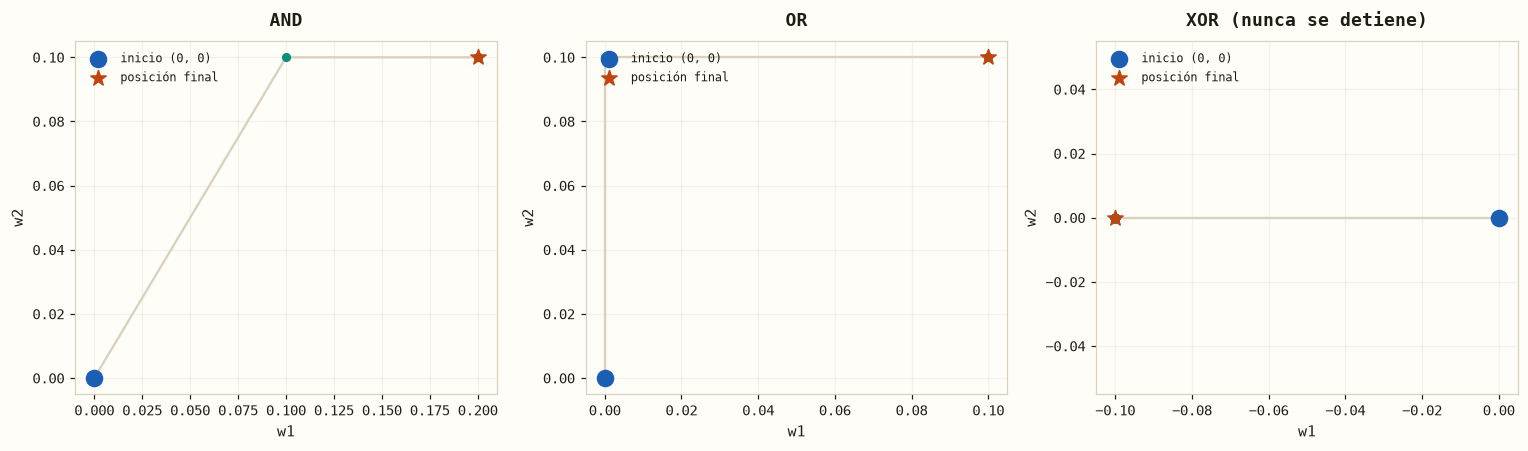

In [10]:
def graficar_trayectoria(perceptron, titulo, ax):
    pesos = np.array([w for w, b in perceptron.weights_history])
    ax.plot(pesos[:, 0], pesos[:, 1], "-", color=COLOR_LINE, linewidth=1.5, zorder=1)
    ax.scatter(pesos[:-1, 0], pesos[:-1, 1], color=COLOR_ACCENT, s=25, zorder=2)
    ax.scatter(*pesos[0], color=COLOR_C0, s=110, marker="o", zorder=3, label="inicio (0, 0)")
    ax.scatter(*pesos[-1], color=COLOR_C1, s=110, marker="*", zorder=3, label="posición final")
    estilizar_ejes(ax, titulo)
    ax.set_xlabel("w1"); ax.set_ylabel("w2")
    leg = ax.legend(loc="upper left", fontsize=8, frameon=False)
    for text in leg.get_texts():
        text.set_color(COLOR_INK)


fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
graficar_trayectoria(perceptron_and, "AND", axes[0])
graficar_trayectoria(perceptron_or, "OR", axes[1])
graficar_trayectoria(perceptron_xor, "XOR (nunca se detiene)", axes[2])
plt.tight_layout()
plt.show()


<a id="7"></a>
## 7. `EXTRA` Comparación conjunta de convergencia

Las tres curvas de error superpuestas en una sola gráfica — se ve de un
vistazo que AND y OR bajan a cero rápido, mientras XOR se queda oscilando sin
bajar nunca de 2 errores.


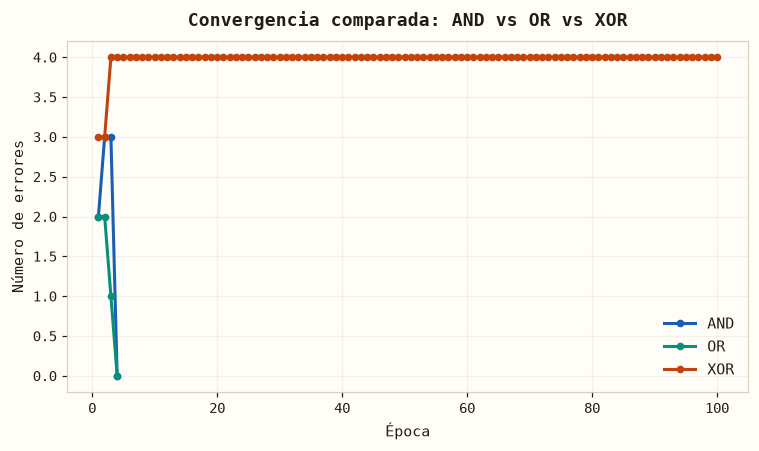

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.2))
for nombre, p, color in [("AND", perceptron_and, COLOR_C0), ("OR", perceptron_or, COLOR_ACCENT), ("XOR", perceptron_xor, COLOR_C1)]:
    ax.plot(range(1, len(p.errors_history) + 1), p.errors_history, marker="o", markersize=4,
            linewidth=2, color=color, label=nombre)
estilizar_ejes(ax, "Convergencia comparada: AND vs OR vs XOR")
ax.set_xlabel("Época"); ax.set_ylabel("Número de errores")
leg = ax.legend(frameon=False)
for text in leg.get_texts():
    text.set_color(COLOR_INK)
plt.tight_layout()
plt.show()


<a id="8"></a>
## 8. `EXTRA` Exactitud (accuracy) final de cada compuerta

La exactitud es la proporción de predicciones correctas sobre el total. Es
la métrica de clasificación más directa para confirmar numéricamente lo que
ya se vio en las gráficas: AND y OR llegan al 100%, XOR se queda en 50-75%
según en qué época se mida (nunca en 100%, porque nunca converge).


In [12]:
for nombre, p, y_gate in [("AND", perceptron_and, y_and), ("OR", perceptron_or, y_or), ("XOR", perceptron_xor, y_xor)]:
    exactitud = p.accuracy(X, y_gate)
    print(f"{nombre}: exactitud = {exactitud * 100:.0f}%")


AND: exactitud = 100%
OR: exactitud = 100%
XOR: exactitud = 50%


<a id="9"></a>
## 9. `EXTRA` Compuerta bonus: NAND

NAND (NOT-AND) es históricamente importante porque es una **compuerta
universal**: cualquier circuito lógico, sin importar qué tan complejo, se
puede construir combinando solo compuertas NAND. Es simplemente el
complemento de AND, así que también es linealmente separable — se espera que
el Perceptrón converja igual de rápido que con AND.


In [13]:
y_nand = np.array([1, 1, 1, 0])

perceptron_nand = Perceptron(input_size=2, learning_rate=0.1, epochs=100)
perceptron_nand.fit(X, y_nand)
print("Pesos finales:", perceptron_nand.weights, " | Bias final:", perceptron_nand.bias)
print(f"Exactitud: {perceptron_nand.accuracy(X, y_nand) * 100:.0f}%")


Convergencia alcanzada en la epoca 6
Pesos finales: [-0.2 -0.1]  | Bias final: 0.2
Exactitud: 100%


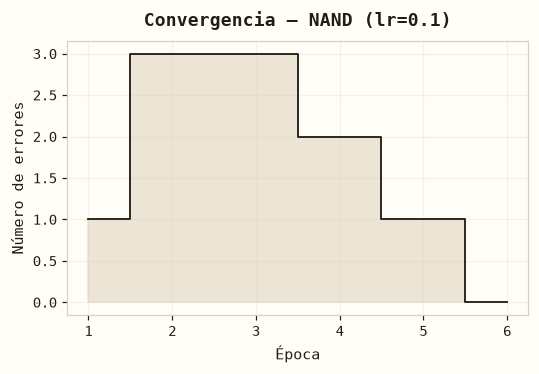

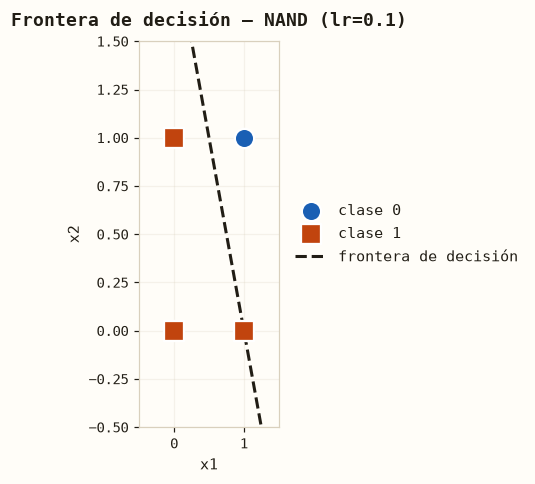

In [14]:
graficar_convergencia(perceptron_nand, "NAND (lr=0.1)")
graficar_frontera(X, y_nand, perceptron_nand, "NAND (lr=0.1)")


<a id="10"></a>
## 10. Comparación de tasa de aprendizaje ($\eta = 0.1$ vs $\eta = 0.01$)

Se repite el entrenamiento de AND y OR con una tasa de aprendizaje 10 veces
menor, para comparar cuántas épocas toma converger.


In [15]:
resultados_lr = []
for nombre, y_gate in [("AND", y_and), ("OR", y_or)]:
    for lr in [0.1, 0.01]:
        p = Perceptron(input_size=2, learning_rate=lr, epochs=200)
        p.fit(X, y_gate)
        epocas_convergencia = len(p.errors_history)
        resultados_lr.append((nombre, lr, epocas_convergencia))

print(f"{'Compuerta':<10}{'lr':<8}{'Epocas hasta convergencia'}")
for nombre, lr, epocas in resultados_lr:
    print(f"{nombre:<10}{lr:<8}{epocas}")


Convergencia alcanzada en la epoca 4
Convergencia alcanzada en la epoca 6
Convergencia alcanzada en la epoca 4
Convergencia alcanzada en la epoca 4
Compuerta lr      Epocas hasta convergencia
AND       0.1     4
AND       0.01    6
OR        0.1     4
OR        0.01    4


<a id="11"></a>
## 11. Cuestionario y análisis

### 11.1 Análisis de convergencia

Con $\eta = 0.1$, el Perceptrón convergió en **muy pocas épocas** tanto para
AND como para OR (ver la impresión "Convergencia alcanzada en la época N" de
cada experimento arriba, y la tabla comparativa de la sección 10). Ambas
compuertas son linealmente separables, así que el algoritmo siempre encuentra
una recta que las separa.

Al comparar $\eta = 0.1$ contra $\eta = 0.01$ (tabla de la sección 10), el
efecto es **desigual entre compuertas**, no un aumento parejo: para **AND**,
la tasa 10 veces menor sí retrasó la convergencia (de 4 a 6 épocas), porque
cada actualización de pesos es más pequeña y toma más pasos alcanzar una
frontera válida. Para **OR**, en cambio, convergió en 4 épocas con ambas
tasas — la región donde una frontera lineal separa correctamente los puntos
de OR es más "ancha" (más combinaciones de pesos funcionan), así que el
tamaño del paso no cambió cuántas épocas hicieron falta en este caso
concreto. En general, una tasa menor **nunca ayuda a converger más rápido**
y en el peor caso lo retrasa — pero cuánto lo retrasa depende de qué tan
ajustada es la región de soluciones válidas para cada problema. La tasa de
aprendizaje no cambia *si* el modelo converge (eso depende únicamente de la
separabilidad lineal de los datos), solo *cuán rápido* lo hace.

### 11.2 El problema de la separabilidad lineal (XOR)

Al entrenar con XOR, el Perceptrón **nunca converge** — el contador de
errores no llega a cero ni se estabiliza en las 100 épocas (ver la gráfica de
convergencia y el listado de errores de las últimas 10 épocas arriba: sigue
oscilando entre 2 y 4 errores indefinidamente). La trayectoria de pesos de la
sección 6 lo muestra de forma aún más directa: para AND y OR el camino se
detiene en un punto; para XOR nunca se detiene, porque no existe ningún punto
$(w_1, w_2)$ que sea una solución.

**Explicación geométrica:** un Perceptrón simple solo puede aprender una
**frontera de decisión lineal** (una recta en 2D, definida por
$w_1 x_1 + w_2 x_2 + b = 0$). Al graficar los 4 puntos de XOR
— $(0,0)\to 0$, $(0,1)\to 1$, $(1,0)\to 1$, $(1,1)\to 0$ — se ve que las
dos clases quedan en **esquinas opuestas** del cuadrado: no existe ninguna
línea recta que dibuje una etiqueta a cada lado. Esto es precisamente el
resultado que Minsky y Papert publicaron en 1969, y que llevó a un
estancamiento en la investigación de redes neuronales durante años ("el
primer invierno de la IA") — hasta que se popularizaron los Perceptrones
**multicapa** (MLP), que sí pueden aprender fronteras no lineales combinando
varias neuronas.

### 11.3 Interpretación de pesos (compuerta AND)

Pesos y bias finales obtenidos para AND (ver salida del experimento 1):


In [16]:
w1, w2 = perceptron_and.weights
b = perceptron_and.bias
print(f"w1 = {w1:.2f}   w2 = {w2:.2f}   bias = {b:.2f}")


w1 = 0.20   w2 = 0.10   bias = -0.20


**Interpretación física:** $w_1$ y $w_2$ representan **cuánto "pesa" o
influye cada entrada** en la decisión final — como ambas entradas de AND
importan por igual, los dos pesos terminan siendo aproximadamente iguales
entre sí (ambas entradas contribuyen simétricamente a que $z$ cruce el
umbral). El **bias** actúa como un "umbral de activación" desplazado: es
el valor que hay que superar con la suma ponderada de las entradas para que
la neurona dispare 1 en vez de 0 — en AND es negativo, porque se necesita
que **ambas** entradas estén activas (sumando su peso) para vencer ese
umbral negativo y cruzar cero; con una sola entrada activa, la suma no
alcanza a compensar el bias y la neurona se queda en 0. En términos
prácticos, el bias es lo que le permite a la neurona no depender únicamente
de que las entradas sean distintas de cero para poder activarse o
desactivarse.


<a id="12"></a>
## 12. `EXTRA` Conclusiones generales

- El Perceptrón simple resuelve **cualquier problema linealmente separable**
  en pocas épocas (AND, OR, NAND), sin importar demasiado la tasa de
  aprendizaje exacta — solo afecta la velocidad, no si converge o no.
- Frente a un problema **no separable linealmente** (XOR), no hay tasa de
  aprendizaje, número de épocas ni inicialización de pesos que lo arregle:
  la limitación es estructural, del modelo (una sola neurona lineal), no de
  los hiperparámetros.
- La trayectoria de pesos (sección 6) es una forma visual muy directa de
  distinguir ambos casos: **se detiene** cuando el problema tiene solución,
  **nunca se detiene** cuando no la tiene.
- Esta limitación histórica (Minsky & Papert, 1969) es exactamente lo que
  motivó el desarrollo de los Perceptrones multicapa y, décadas después, del
  *deep learning* moderno.

Como complemento a este cuaderno, el mismo algoritmo corre en vivo en un
simulador interactivo desplegado públicamente:
**https://perceptron-3lsq84czlgcncqnhgoiqh9.streamlit.app** (código fuente en
https://github.com/Calamar49/Perceptron), donde se puede elegir la compuerta,
la tasa de aprendizaje y recorrer época por época la frontera de decisión.

### Referencias

- Rosenblatt, F. (1958). *The perceptron: A probabilistic model for
  information storage and organization in the brain.* Psychological Review,
  65(6), 386–408.
- Minsky, M., & Papert, S. (1969). *Perceptrons: An Introduction to
  Computational Geometry.* MIT Press.
